**Dataset:** Ultrasound images — PCOS vs Normal  
**Train:** 675 PCOS + 913 Normal = 1,588 images  
**Test:**  169 PCOS + 229 Normal = 398 images  
**Image Size:** 128×128 | **Epochs:** 10+

---
#  SECTION 1: Mount Google Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


---
#  SECTION 2: Install & Import All Libraries

In [ ]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

import tensorflow as tf
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import (
    Conv2D, MaxPooling2D, Flatten,
    Dense, Dropout, BatchNormalization,
    GlobalAveragePooling2D, GaussianNoise
)
from tensorflow.keras.applications import MobileNetV2, ResNet50V2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input as mobilenet_preprocess
from tensorflow.keras.applications.resnet_v2   import preprocess_input as resnet_preprocess
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam
from tensorflow.keras import regularizers
from tensorflow.keras.losses import BinaryCrossentropy
from tensorflow.keras.preprocessing import image as keras_image


from sklearn.metrics import classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight

# Fix seeds for reproducibility
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)
random.seed(SEED)

print('TensorFlow :', tf.__version__)
print('GPU        :', tf.config.list_physical_devices('GPU'))

TensorFlow : 2.19.0
GPU        : [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


---
# SECTION 3: Shared Configuration & Paths

In [ ]:
# Update this path to your dataset location
BASE_DIR  = '/content/drive/MyDrive/DL/archive (12)/Dataset'
TRAIN_DIR = os.path.join(BASE_DIR, 'Train')
TEST_DIR  = os.path.join(BASE_DIR, 'Test')

IMG_SIZE   = (128, 128)
BATCH_SIZE = 16      # Small batch = noisier gradients = harder to overfit
EPOCHS     = 30

# Storage for results comparison at the end
all_results = {}

# Verify paths
for folder in [TRAIN_DIR, TEST_DIR]:
    status = 'yes' if os.path.exists(folder) else 'NOT FOUND'
    print(f"{status}  {folder}")

print()
for split, path in [('Train', TRAIN_DIR), ('Test', TEST_DIR)]:
    for cls in sorted(os.listdir(path)):
        cls_path = os.path.join(path, cls)
        if os.path.isdir(cls_path):
            print(f"  {split} — {cls}: {len(os.listdir(cls_path))} images")

yes  /content/drive/MyDrive/DL/archive (12)/Dataset/Train
yes  /content/drive/MyDrive/DL/archive (12)/Dataset/Test

  Train — NORMAL: 913 images
  Train — PCOS: 675 images
  Test — NORMAL: 229 images
  Test — PCOS: 169 images


---
# SECTION 4: Shared Helper Functions
These functions are reused by all 3 models — run once.

In [ ]:
# ── Helper: Build data generators ───────────────────────────────────────────
def build_generators(preprocess_fn, batch_size=BATCH_SIZE):
    """Creates train (with val split), val, and test generators."""
    train_datagen = ImageDataGenerator(
        preprocessing_function=preprocess_fn,
        rotation_range=40,
        zoom_range=0.3,
        horizontal_flip=True,
        vertical_flip=True,
        width_shift_range=0.25,
        height_shift_range=0.25,
        shear_range=0.20,
        brightness_range=[0.7, 1.3],
        fill_mode='reflect',
        validation_split=0.20   # 20% of train = validation
    )
    test_datagen = ImageDataGenerator(preprocessing_function=preprocess_fn)

    train_gen = train_datagen.flow_from_directory(
        TRAIN_DIR, target_size=IMG_SIZE,
        batch_size=batch_size, class_mode='binary',
        subset='training', shuffle=True, seed=SEED
    )
    val_gen = train_datagen.flow_from_directory(
        TRAIN_DIR, target_size=IMG_SIZE,
        batch_size=batch_size, class_mode='binary',
        subset='validation', shuffle=False, seed=SEED
    )
    test_gen = test_datagen.flow_from_directory(
        TEST_DIR, target_size=IMG_SIZE,
        batch_size=batch_size, class_mode='binary',
        shuffle=False
    )
    return train_gen, val_gen, test_gen


# ── Helper: Compute class weights ──────────────────────────────────────────
def get_class_weights(train_gen):
    labels = train_gen.classes
    weights = compute_class_weight('balanced', classes=np.unique(labels), y=labels)
    cw = dict(zip(np.unique(labels), weights))
    print(f"  Class weights: {cw}")
    return cw


# # ── Helper: Standard callbacks ─────────────────────────────────────────────
# def get_callbacks(model_name):
#     return [
#         EarlyStopping(monitor='val_loss', patience=4,
#                       restore_best_weights=True, verbose=1),
#         ModelCheckpoint(f'best_{model_name}.keras', monitor='val_accuracy',
#                         save_best_only=True, verbose=0),
#         ReduceLROnPlateau(monitor='val_loss', factor=0.3,
#                           patience=2, min_lr=1e-8, verbose=1)
#     ]


# ── Helper: Plot training curves ──────────────────────────────────────────
def plot_history(history, model_name):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    epochs_ran = range(1, len(history.history['accuracy']) + 1)

    # Accuracy
    axes[0].plot(epochs_ran, history.history['accuracy'],
                 label='Train', linewidth=2, marker='o', markersize=5, color='steelblue')
    axes[0].plot(epochs_ran, history.history['val_accuracy'],
                 label='Val', linewidth=2, marker='s', markersize=5,
                 linestyle='--', color='darkorange')
    axes[0].fill_between(epochs_ran,
                         history.history['accuracy'],
                         history.history['val_accuracy'],
                         alpha=0.1, color='gray')
    tr_acc = history.history['accuracy'][-1]
    vl_acc = history.history['val_accuracy'][-1]
    gap    = abs(tr_acc - vl_acc)
    color  = 'green' if gap < 0.07 else 'red'
    axes[0].annotate(
        f'Gap: {gap*100:.1f}% — {"Healthy " if gap < 0.07 else "Overfit "}',
        xy=(0.5, 0.04), xycoords='axes fraction', ha='center',
        fontsize=10, color=color,
        bbox=dict(boxstyle='round,pad=0.3', facecolor='lightyellow',
                  edgecolor=color, alpha=0.8)
    )
    axes[0].set_title(f'{model_name} — Accuracy', fontsize=13, fontweight='bold')
    axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Accuracy')
    axes[0].set_ylim([0.5, 1.02]); axes[0].legend(); axes[0].grid(True, alpha=0.3)

    # Loss
    axes[1].plot(epochs_ran, history.history['loss'],
                 label='Train', linewidth=2, marker='o', markersize=5, color='steelblue')
    axes[1].plot(epochs_ran, history.history['val_loss'],
                 label='Val', linewidth=2, marker='s', markersize=5,
                 linestyle='--', color='darkorange')
    axes[1].set_title(f'{model_name} — Loss', fontsize=13, fontweight='bold')
    axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Loss')
    axes[1].legend(); axes[1].grid(True, alpha=0.3)

    plt.suptitle(f'{model_name} — Training Curves', fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()
    print(f'  Train Acc: {tr_acc*100:.2f}%  |  Val Acc: {vl_acc*100:.2f}%  |  Gap: {gap*100:.2f}%')


# ── Helper: Evaluate + confusion matrix ──────────────────────────────────
def evaluate_model(model, test_gen, model_name, class_names):
    test_loss, test_acc = model.evaluate(test_gen, verbose=0)
    print(f'\n {model_name} Test Accuracy : {test_acc*100:.2f}%')
    print(f'{model_name} Test Loss     : {test_loss:.4f}')

    test_gen.reset()
    preds  = model.predict(test_gen, verbose=0)
    y_pred = (preds > 0.4).astype(int).flatten()
    y_true = test_gen.classes

    print(f'\nClassification Report — {model_name}')
    print(classification_report(y_true, y_pred, target_names=class_names))

    cm      = confusion_matrix(y_true, y_pred)
    cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names, ax=axes[0])
    axes[0].set_title('Counts', fontsize=12, fontweight='bold')
    axes[0].set_xlabel('Predicted'); axes[0].set_ylabel('Actual')

    sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='YlOrRd',
                xticklabels=class_names, yticklabels=class_names,
                ax=axes[1], vmin=0, vmax=1)
    axes[1].set_title('Normalized', fontsize=12, fontweight='bold')
    axes[1].set_xlabel('Predicted'); axes[1].set_ylabel('Actual')

    plt.suptitle(f'{model_name} — Confusion Matrix', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()

    tn, fp, fn, tp = cm.ravel()
    sensitivity = tp / (tp + fn) * 100
    specificity = tn / (tn + fp) * 100
    print(f'  Sensitivity (PCOS Recall)  : {sensitivity:.1f}%')
    print(f'  Specificity (Normal Recall): {specificity:.1f}%')

    return {
        'test_acc' : test_acc,
        'test_loss': test_loss,
        'sensitivity': sensitivity,
        'specificity': specificity,
        'cm_norm': cm_norm
    }


print(' All helper functions loaded.')

 All helper functions loaded.


---
# SECTION 5: Visualize Sample + Augmented Images

Found 1588 images belonging to 2 classes.


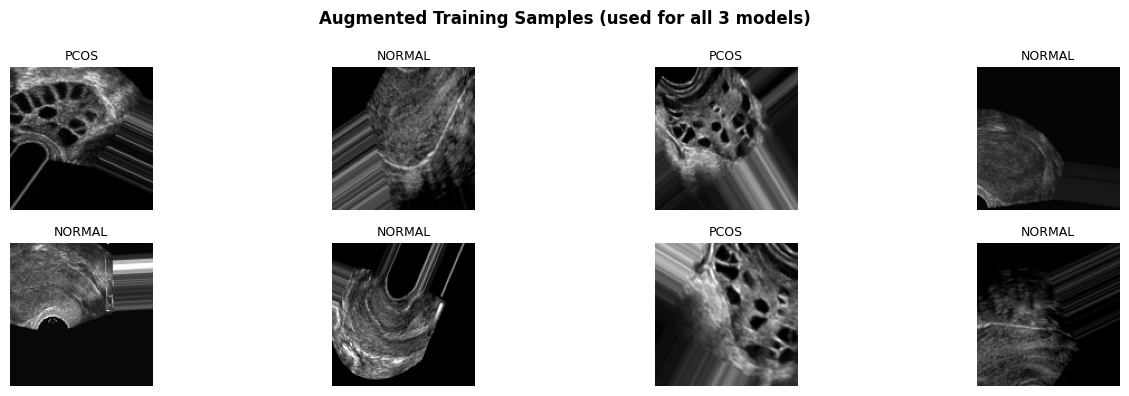

In [ ]:
viz_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=40, zoom_range=0.3,
    horizontal_flip=True, vertical_flip=True,
    width_shift_range=0.25, height_shift_range=0.25,
    brightness_range=[0.7, 1.3]
)
viz_gen = viz_datagen.flow_from_directory(
    TRAIN_DIR, target_size=IMG_SIZE,
    batch_size=8, class_mode='binary', shuffle=True, seed=SEED
)
class_names_viz = list(viz_gen.class_indices.keys())
images, labels  = next(viz_gen)

plt.figure(figsize=(14, 4))
for i in range(8):
    plt.subplot(2, 4, i+1)
    plt.imshow(images[i])
    plt.title(class_names_viz[int(labels[i])], fontsize=9)
    plt.axis('off')
plt.suptitle('Augmented Training Samples (used for all 3 models)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

---
# SECTION 6: Model 1 — Custom CNN (From Scratch)


In [ ]:
print('=' * 55)
print('  MODEL 1: Custom CNN — Building...')
print('=' * 55)

# CNN uses simple rescale (no pretrained preprocessing needed)
def cnn_preprocess(img):
    return img / 255.0

cnn_train_gen, cnn_val_gen, cnn_test_gen = build_generators(cnn_preprocess)
cnn_class_names = list(cnn_train_gen.class_indices.keys())
cnn_class_weights = get_class_weights(cnn_train_gen)

# Build CNN
cnn_model = Sequential([
    # Input noise — breaks perfect pixel memorization
    GaussianNoise(0.05, input_shape=(128, 128, 3)),

    # Block 1
    Conv2D(32, (3,3), activation='relu', padding='same',
           kernel_regularizer=regularizers.l2(0.001)),
    BatchNormalization(),
    MaxPooling2D(2, 2),
    Dropout(0.25),

    # Block 2
    Conv2D(64, (3,3), activation='relu', padding='same',
           kernel_regularizer=regularizers.l2(0.001)),
    BatchNormalization(),
    MaxPooling2D(2, 2),
    Dropout(0.25),

    # Block 3
    Conv2D(128, (3,3), activation='relu', padding='same',
           kernel_regularizer=regularizers.l2(0.001)),
    BatchNormalization(),
    MaxPooling2D(2, 2),
    Dropout(0.30),

    # Classifier head
    Flatten(),
    Dense(128, activation='relu',
          kernel_regularizer=regularizers.l2(0.01)),
    Dropout(0.50),
    Dense(1, activation='sigmoid')
])

cnn_model.compile(
    optimizer=Adam(learning_rate=5e-4),
    loss=BinaryCrossentropy(label_smoothing=0.15),   # KEY FIX
    metrics=['accuracy']
)

cnn_model.summary()
print('\n CNN model built.')

  MODEL 1: Custom CNN — Building...
Found 1271 images belonging to 2 classes.
Found 317 images belonging to 2 classes.
Found 398 images belonging to 2 classes.
  Class weights: {np.int32(0): np.float64(0.8693570451436389), np.int32(1): np.float64(1.1768518518518518)}


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gaussian_noise (GaussianNoise)  │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     4,194,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,288,705 (16.36 MB)

 Trainable params: 4,288,257 (16.36 MB)

 Non-trainable params: 448 (1.75 KB)


 CNN model built.


In [ ]:
print('\n Training CNN...')
cnn_history = cnn_model.fit(
    cnn_train_gen,
    epochs=EPOCHS,
    validation_data=cnn_val_gen,
    class_weight=cnn_class_weights
)


 Training CNN...
Epoch 1/30
80/80 ━━━━━━━━━━━━━━━━━━━━ 330s 4s/step - accuracy: 0.6814 - loss: 3.3902 - val_accuracy: 0.5741 - val_loss: 11.6789
Epoch 2/30
80/80 ━━━━━━━━━━━━━━━━━━━━ 15s 184ms/step - accuracy: 0.8348 - loss: 2.0409 - val_accuracy: 0.5741 - val_loss: 11.8625
Epoch 3/30
80/80 ━━━━━━━━━━━━━━━━━━━━ 15s 184ms/step - accuracy: 0.8875 - loss: 1.6317 - val_accuracy: 0.6435 - val_loss: 1.9082
Epoch 4/30
80/80 ━━━━━━━━━━━━━━━━━━━━ 15s 185ms/step - accuracy: 0.9213 - loss: 1.3356 - val_accuracy: 0.4259 - val_loss: 5.7077
Epoch 5/30
80/80 ━━━━━━━━━━━━━━━━━━━━ 14s 181ms/step - accuracy: 0.9260 - loss: 1.1713 - val_accuracy: 0.4259 - val_loss: 6.2267
Epoch 6/30
80/80 ━━━━━━━━━━━━━━━━━━━━ 15s 182ms/step - accuracy: 0.9520 - loss: 0.9808 - val_accuracy: 0.4259 - val_loss: 6.3105
Epoch 7/30
80/80 ━━━━━━━━━━━━━━━━━━━━ 23s 208ms/step - accuracy: 0.9449 - loss: 0.9140 - val_accuracy: 0.4259 - val_loss: 5.9489
Epoch 8/30
80/80 ━━━━━━━━━━━━━━━━━━━━ 15s 192ms/step - accuracy: 0.9646 - loss:

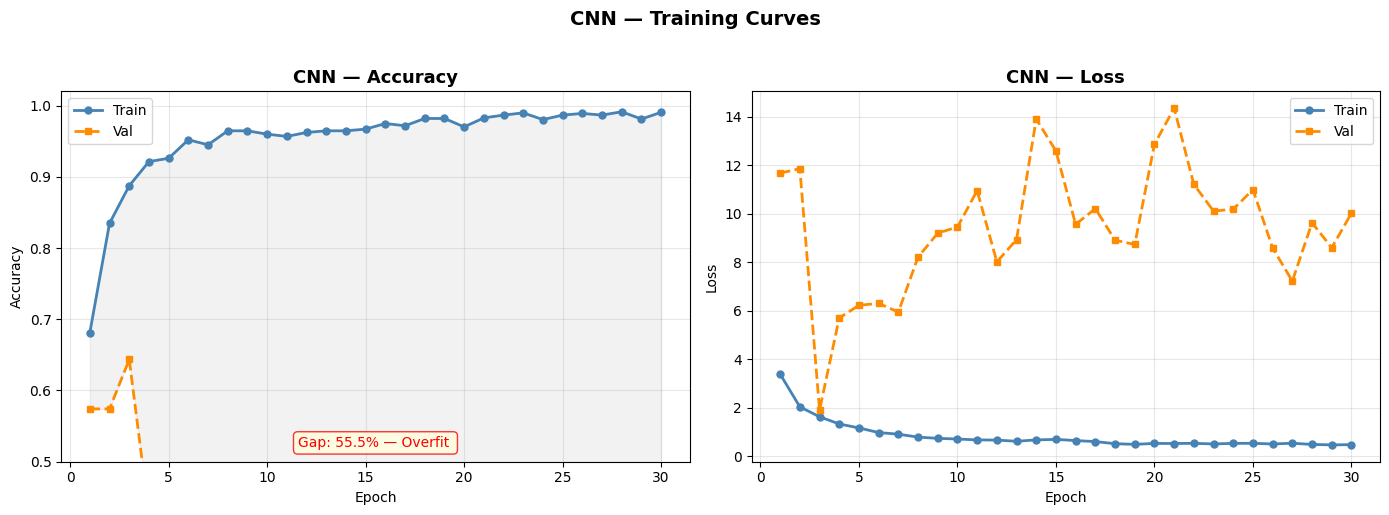

  Train Acc: 99.06%  |  Val Acc: 43.53%  |  Gap: 55.52%

 CNN Test Accuracy : 42.46%
CNN Test Loss     : 7.5565

Classification Report — CNN
              precision    recall  f1-score   support

      NORMAL       0.00      0.00      0.00       229
        PCOS       0.42      1.00      0.60       169

    accuracy                           0.42       398
   macro avg       0.21      0.50      0.30       398
weighted avg       0.18      0.42      0.25       398



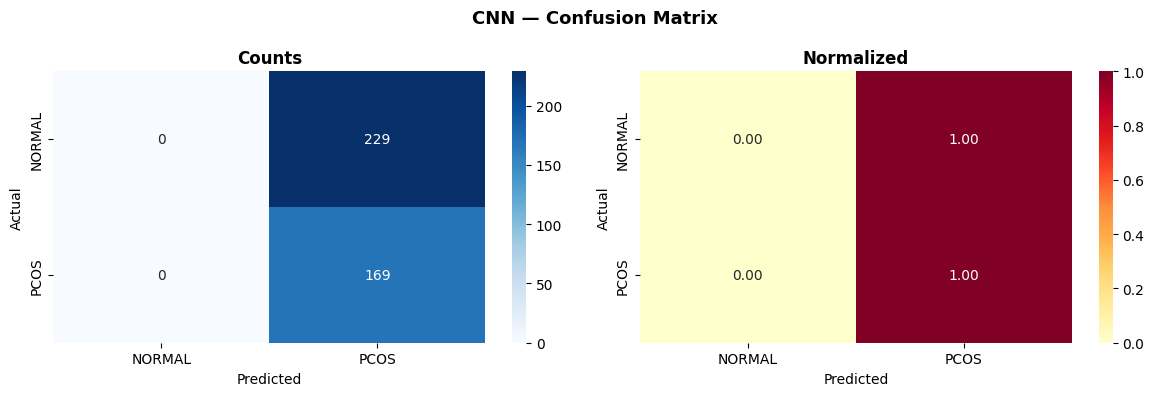

  Sensitivity (PCOS Recall)  : 100.0%
  Specificity (Normal Recall): 0.0%

  CNN evaluation done. Results stored.


In [ ]:
plot_history(cnn_history, 'CNN')
cnn_results = evaluate_model(cnn_model, cnn_test_gen, 'CNN', cnn_class_names)
all_results['CNN'] = cnn_results
print('\n  CNN evaluation done. Results stored.')

---
#  SECTION 7: Model 2 — MobileNetV2 (Transfer Learning)



In [ ]:
print('=' * 55)
print('  MODEL 2: MobileNetV2 — Building...')
print('=' * 55)

mob_train_gen, mob_val_gen, mob_test_gen = build_generators(mobilenet_preprocess)
mob_class_names   = list(mob_train_gen.class_indices.keys())
mob_class_weights = get_class_weights(mob_train_gen)

# Load MobileNetV2
mob_base = MobileNetV2(
    input_shape=(128, 128, 3),
    include_top=False,
    weights='imagenet'
)

# 🔥 Unfreeze last 10 layers
mob_base.trainable = True
for layer in mob_base.layers[:-10]:
    layer.trainable = False

# Build head
x = mob_base.output
x = GlobalAveragePooling2D()(x)
x = GaussianNoise(0.20)(x)
x = BatchNormalization()(x)
x = Dense(128, activation='relu',
           kernel_regularizer=regularizers.l2(0.01))(x)
x = Dropout(0.30)(x)
x = Dense(64, activation='relu',
           kernel_regularizer=regularizers.l2(0.01))(x)
x = Dropout(0.30)(x)
mob_out = Dense(1, activation='sigmoid')(x)

mob_model = Model(inputs=mob_base.input, outputs=mob_out)

# 🔧 Use LOWER LR for fine-tuning
mob_model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss=BinaryCrossentropy(label_smoothing=0.05),
    metrics=['accuracy']
)

# 🔍 Proper checks
trainable_params = sum([tf.size(w).numpy() for w in mob_model.trainable_weights])
trainable_layers = sum([layer.trainable for layer in mob_base.layers])

print(f'Trainable params  : {trainable_params:,}')
print(f'Trainable layers (base): {trainable_layers}')
print(f'Total params      : {mob_model.count_params():,}')

print('\n MobileNetV2 model built (last 10 layers unfrozen).')

  MODEL 2: MobileNetV2 — Building...
Found 1271 images belonging to 2 classes.
Found 317 images belonging to 2 classes.
Found 398 images belonging to 2 classes.
  Class weights: {np.int32(0): np.float64(0.8693570451436389), np.int32(1): np.float64(1.1768518518518518)}
9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Trainable params  : 907,329
Trainable layers (base): 10
Total params      : 2,435,393

 MobileNetV2 model built (last 10 layers unfrozen).


In [ ]:
print('\n  Training MobileNetV2...')
mob_history = mob_model.fit(
    mob_train_gen,
    epochs=EPOCHS,
    validation_data=mob_val_gen,
    class_weight=mob_class_weights
)


  Training MobileNetV2...
Epoch 1/30
80/80 ━━━━━━━━━━━━━━━━━━━━ 71s 609ms/step - accuracy: 0.6082 - loss: 3.9547 - val_accuracy: 0.7666 - val_loss: 3.6818
Epoch 2/30
80/80 ━━━━━━━━━━━━━━━━━━━━ 15s 186ms/step - accuracy: 0.7396 - loss: 3.7604 - val_accuracy: 0.8833 - val_loss: 3.5415
Epoch 3/30
80/80 ━━━━━━━━━━━━━━━━━━━━ 15s 182ms/step - accuracy: 0.8072 - loss: 3.6302 - val_accuracy: 0.9527 - val_loss: 3.4227
Epoch 4/30
80/80 ━━━━━━━━━━━━━━━━━━━━ 15s 193ms/step - accuracy: 0.8442 - loss: 3.5648 - val_accuracy: 0.9590 - val_loss: 3.3842
Epoch 5/30
80/80 ━━━━━━━━━━━━━━━━━━━━ 15s 184ms/step - accuracy: 0.8788 - loss: 3.5096 - val_accuracy: 0.9621 - val_loss: 3.3491
Epoch 6/30
80/80 ━━━━━━━━━━━━━━━━━━━━ 15s 186ms/step - accuracy: 0.9056 - loss: 3.4443 - val_accuracy: 0.9811 - val_loss: 3.3111
Epoch 7/30
80/80 ━━━━━━━━━━━━━━━━━━━━ 15s 183ms/step - accuracy: 0.9119 - loss: 3.4167 - val_accuracy: 0.9748 - val_loss: 3.3098
Epoch 8/30
80/80 ━━━━━━━━━━━━━━━━━━━━ 15s 185ms/step - accuracy: 0.928

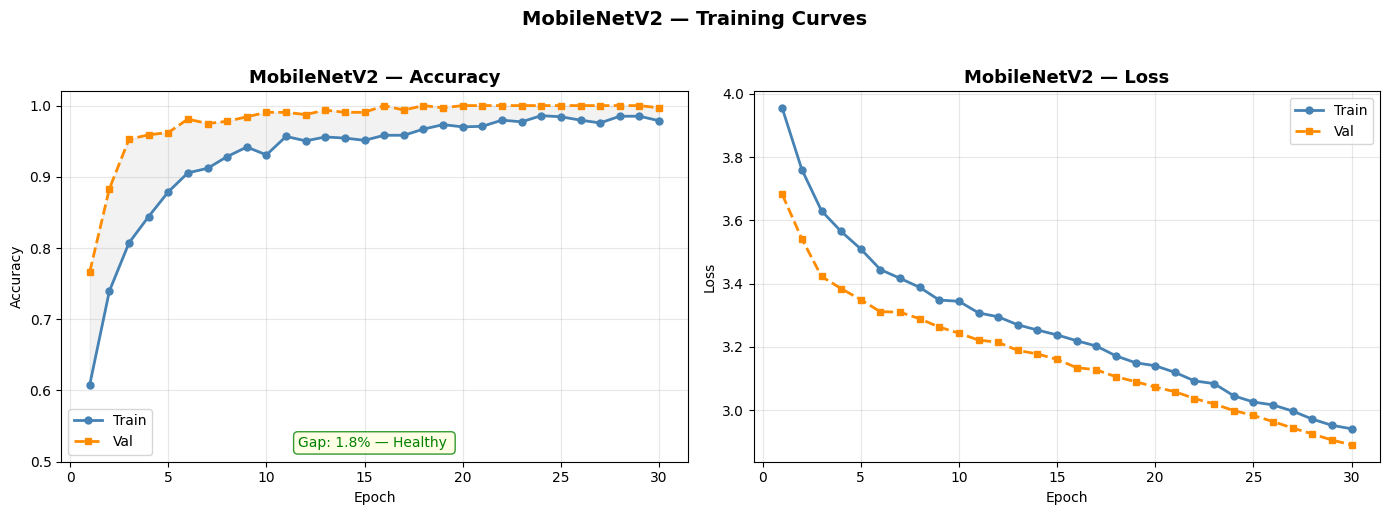

  Train Acc: 97.88%  |  Val Acc: 99.68%  |  Gap: 1.81%

 MobileNetV2 Test Accuracy : 92.46%
MobileNetV2 Test Loss     : 3.0322

Classification Report — MobileNetV2
              precision    recall  f1-score   support

      NORMAL       0.90      1.00      0.95       229
        PCOS       1.00      0.85      0.92       169

    accuracy                           0.93       398
   macro avg       0.95      0.92      0.93       398
weighted avg       0.94      0.93      0.93       398



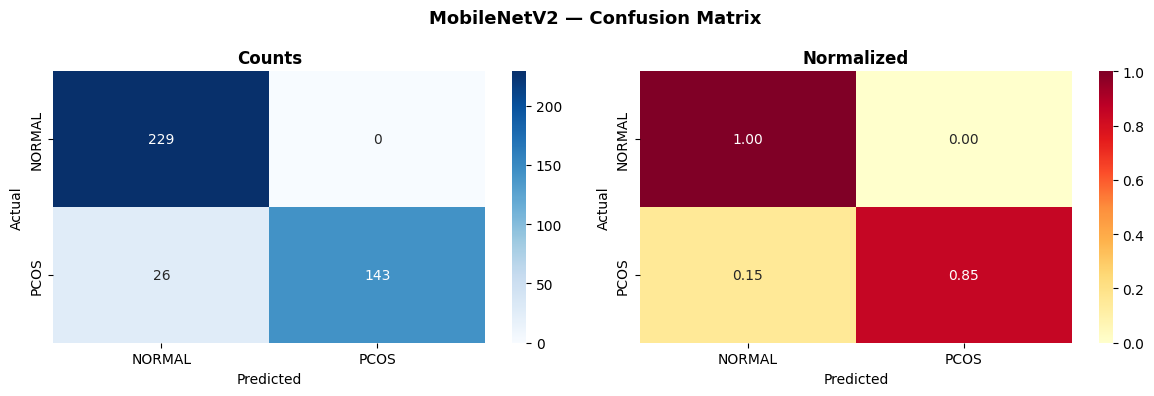

  Sensitivity (PCOS Recall)  : 84.6%
  Specificity (Normal Recall): 100.0%

 MobileNetV2 evaluation done. Results stored.


In [ ]:
plot_history(mob_history, 'MobileNetV2')
mob_results = evaluate_model(mob_model, mob_test_gen, 'MobileNetV2', mob_class_names)
all_results['MobileNetV2'] = mob_results
print('\n MobileNetV2 evaluation done. Results stored.')

---
#  SECTION 8: Model 3 — ResNet50V2 (Transfer Learning)



In [ ]:
print('=' * 55)
print('  MODEL 3: ResNet50V2 — Building...')
print('=' * 55)

res_train_gen, res_val_gen, res_test_gen = build_generators(resnet_preprocess)
res_class_names   = list(res_train_gen.class_indices.keys())
res_class_weights = get_class_weights(res_train_gen)

# Load ResNet50V2
res_base = ResNet50V2(
    input_shape=(128, 128, 3),
    include_top=False,
    weights='imagenet'
)

# Freeze all, then unfreeze only last 2 residual blocks
res_base.trainable = True
for layer in res_base.layers:
    layer.trainable = False

unfreeze_blocks = ['conv5_block2', 'conv5_block3']
for layer in res_base.layers:
    if any(layer.name.startswith(b) for b in unfreeze_blocks):
        layer.trainable = True

unfrozen_count = sum(1 for l in res_base.layers if l.trainable)
print(f'Unfrozen ResNet layers: {unfrozen_count} (conv5_block2 + conv5_block3 only)')

# Build head
x = res_base.output
x = GlobalAveragePooling2D()(x)
x = GaussianNoise(0.35)(x)              # Highest noise — ResNet features are very powerful
x = BatchNormalization()(x)
x = Dense(128, activation='relu',
           kernel_regularizer=regularizers.l2(0.02))(x)
x = Dropout(0.50)(x)
x = Dense(64, activation='relu',
           kernel_regularizer=regularizers.l2(0.02))(x)
x = Dropout(0.40)(x)
res_out = Dense(1, activation='sigmoid')(x)

res_model = Model(inputs=res_base.input, outputs=res_out)

res_model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss=BinaryCrossentropy(label_smoothing=0.15),   # KEY FIX
    metrics=['accuracy']
)

trainable = sum([tf.size(w).numpy() for w in res_model.trainable_weights])
print(f'Trainable params  : {trainable:,}')
print(f'Total params      : {res_model.count_params():,}')
print('\n ResNet50V2 model built.')

  MODEL 3: ResNet50V2 — Building...
Found 1271 images belonging to 2 classes.
Found 317 images belonging to 2 classes.
Found 398 images belonging to 2 classes.
  Class weights: {np.int32(0): np.float64(0.8693570451436389), np.int32(1): np.float64(1.1768518518518518)}
94668760/94668760 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Unfrozen ResNet layers: 22 (conv5_block2 + conv5_block3 only)
Trainable params  : 9,203,969
Total params      : 23,843,585

 ResNet50V2 model built.


In [ ]:
print('\n  Training ResNet50V2...')
res_history = res_model.fit(
    res_train_gen,
    epochs=EPOCHS,
    validation_data=res_val_gen,
    class_weight=res_class_weights
)


  Training ResNet50V2...
Epoch 1/30
80/80 ━━━━━━━━━━━━━━━━━━━━ 49s 382ms/step - accuracy: 0.4689 - loss: 7.5392 - val_accuracy: 0.4890 - val_loss: 7.3002
Epoch 2/30
80/80 ━━━━━━━━━━━━━━━━━━━━ 15s 190ms/step - accuracy: 0.5319 - loss: 7.4029 - val_accuracy: 0.5994 - val_loss: 7.0879
Epoch 3/30
80/80 ━━━━━━━━━━━━━━━━━━━━ 15s 189ms/step - accuracy: 0.5523 - loss: 7.3260 - val_accuracy: 0.6656 - val_loss: 7.0232
Epoch 4/30
80/80 ━━━━━━━━━━━━━━━━━━━━ 21s 192ms/step - accuracy: 0.6003 - loss: 7.1923 - val_accuracy: 0.7792 - val_loss: 6.9164
Epoch 5/30
80/80 ━━━━━━━━━━━━━━━━━━━━ 16s 194ms/step - accuracy: 0.6286 - loss: 7.1227 - val_accuracy: 0.8738 - val_loss: 6.8379
Epoch 6/30
80/80 ━━━━━━━━━━━━━━━━━━━━ 16s 201ms/step - accuracy: 0.6924 - loss: 7.0243 - val_accuracy: 0.9495 - val_loss: 6.7573
Epoch 7/30
80/80 ━━━━━━━━━━━━━━━━━━━━ 16s 197ms/step - accuracy: 0.7199 - loss: 6.9378 - val_accuracy: 0.9274 - val_loss: 6.7094
Epoch 8/30
80/80 ━━━━━━━━━━━━━━━━━━━━ 16s 194ms/step - accuracy: 0.7640

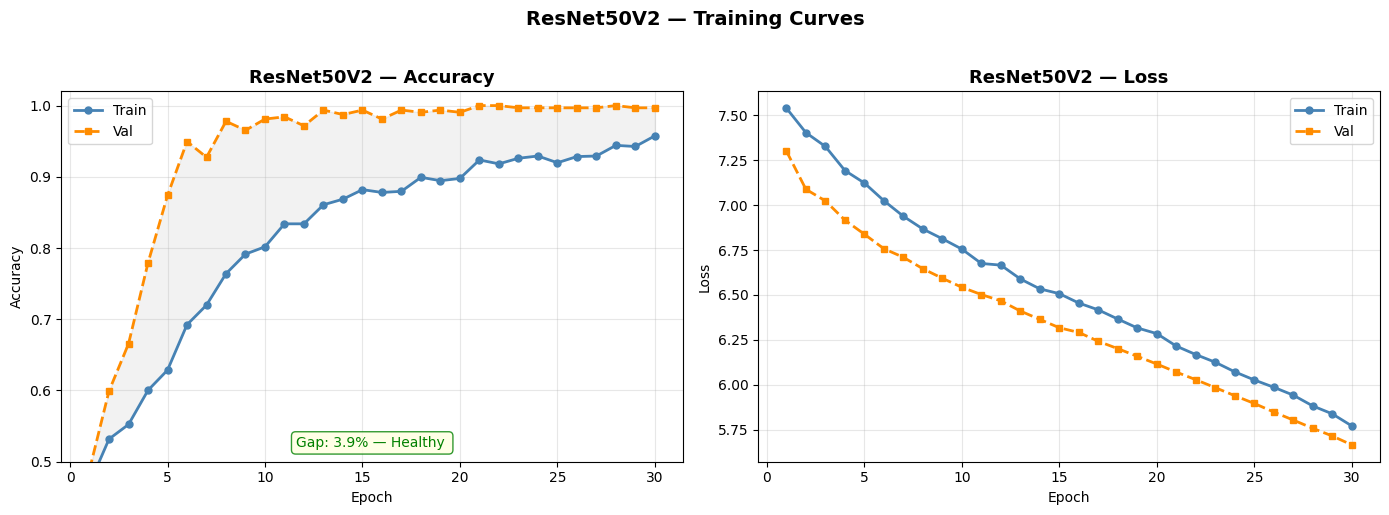

  Train Acc: 95.75%  |  Val Acc: 99.68%  |  Gap: 3.93%

 ResNet50V2 Test Accuracy : 97.74%
ResNet50V2 Test Loss     : 5.7066

Classification Report — ResNet50V2
              precision    recall  f1-score   support

      NORMAL       0.97      1.00      0.99       229
        PCOS       1.00      0.96      0.98       169

    accuracy                           0.98       398
   macro avg       0.99      0.98      0.98       398
weighted avg       0.99      0.98      0.98       398



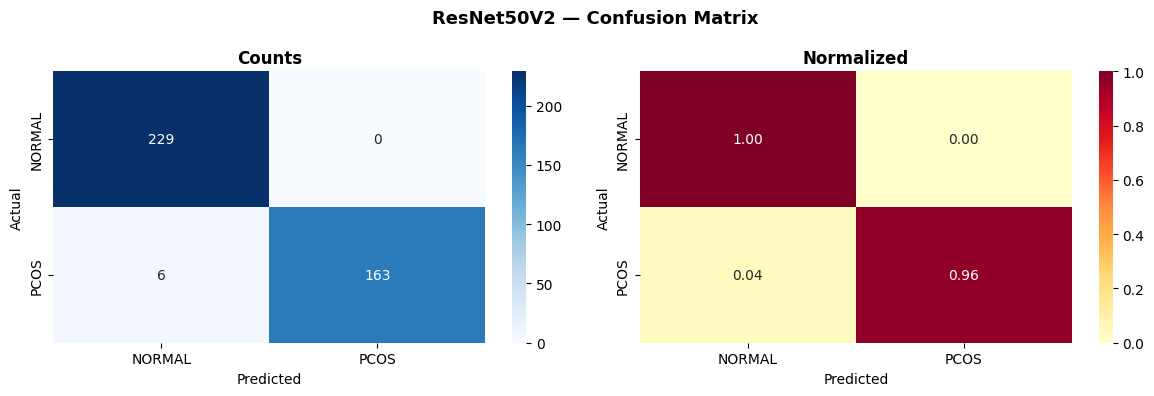

  Sensitivity (PCOS Recall)  : 96.4%
  Specificity (Normal Recall): 100.0%

 ResNet50V2 evaluation done. Results stored.


In [ ]:
plot_history(res_history, 'ResNet50V2')
res_results = evaluate_model(res_model, res_test_gen, 'ResNet50V2', res_class_names)
all_results['ResNet50V2'] = res_results
print('\n ResNet50V2 evaluation done. Results stored.')

---
#  SECTION 9: Final Comparison — All 3 Models Side by Side

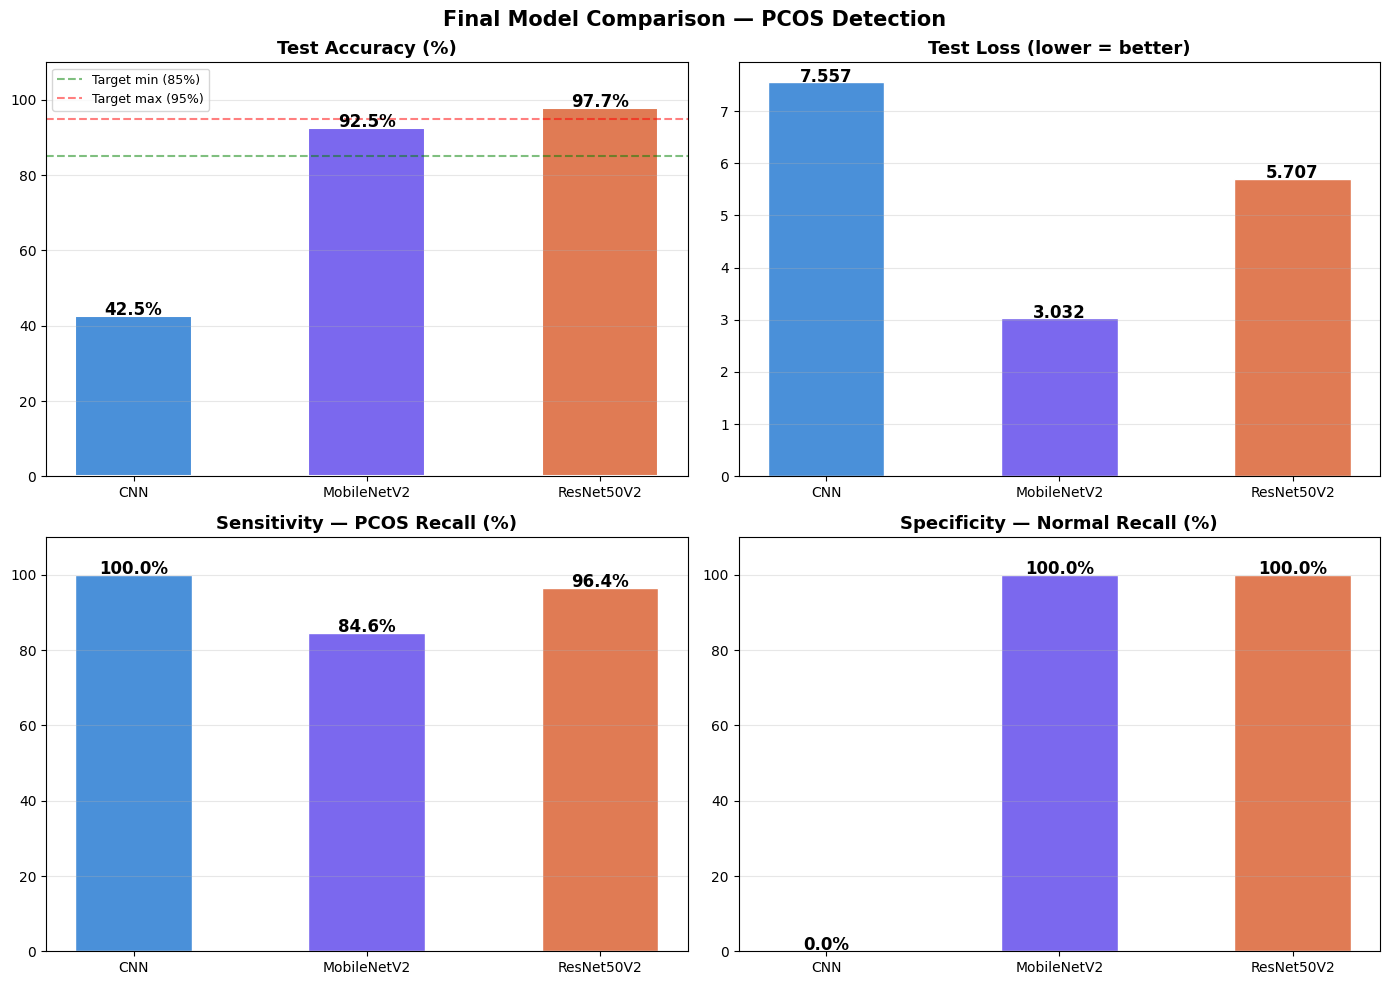

In [ ]:
model_names = list(all_results.keys())
test_accs   = [all_results[m]['test_acc']    * 100 for m in model_names]
test_losses = [all_results[m]['test_loss']          for m in model_names]
sensitivities = [all_results[m]['sensitivity']      for m in model_names]
specificities = [all_results[m]['specificity']      for m in model_names]

colors = ['#4A90D9', '#7B68EE', '#E07B54']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1 — Test Accuracy
bars = axes[0,0].bar(model_names, test_accs, color=colors, width=0.5, edgecolor='white', linewidth=1.5)
for bar, val in zip(bars, test_accs):
    axes[0,0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                   f'{val:.1f}%', ha='center', fontweight='bold', fontsize=12)
axes[0,0].set_title('Test Accuracy (%)', fontsize=13, fontweight='bold')
axes[0,0].set_ylim([0, 110])
axes[0,0].axhline(y=85, color='green', linestyle='--', alpha=0.5, label='Target min (85%)')
axes[0,0].axhline(y=95, color='red',   linestyle='--', alpha=0.5, label='Target max (95%)')
axes[0,0].legend(fontsize=9)
axes[0,0].grid(axis='y', alpha=0.3)

# Plot 2 — Test Loss
bars2 = axes[0,1].bar(model_names, test_losses, color=colors, width=0.5, edgecolor='white')
for bar, val in zip(bars2, test_losses):
    axes[0,1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                   f'{val:.3f}', ha='center', fontweight='bold', fontsize=12)
axes[0,1].set_title('Test Loss (lower = better)', fontsize=13, fontweight='bold')
axes[0,1].grid(axis='y', alpha=0.3)

# Plot 3 — Sensitivity
bars3 = axes[1,0].bar(model_names, sensitivities, color=colors, width=0.5, edgecolor='white')
for bar, val in zip(bars3, sensitivities):
    axes[1,0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                   f'{val:.1f}%', ha='center', fontweight='bold', fontsize=12)
axes[1,0].set_title('Sensitivity — PCOS Recall (%)', fontsize=13, fontweight='bold')
axes[1,0].set_ylim([0, 110])
axes[1,0].grid(axis='y', alpha=0.3)

# Plot 4 — Specificity
bars4 = axes[1,1].bar(model_names, specificities, color=colors, width=0.5, edgecolor='white')
for bar, val in zip(bars4, specificities):
    axes[1,1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                   f'{val:.1f}%', ha='center', fontweight='bold', fontsize=12)
axes[1,1].set_title('Specificity — Normal Recall (%)', fontsize=13, fontweight='bold')
axes[1,1].set_ylim([0, 110])
axes[1,1].grid(axis='y', alpha=0.3)

plt.suptitle('Final Model Comparison — PCOS Detection', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
# Summary table
print('\n' + '=' * 68)
print(f"  {'Model':<15} {'Test Acc':>10} {'Test Loss':>10} {'Sensitivity':>13} {'Specificity':>13}")
print('  ' + '-' * 64)
for m in model_names:
    r = all_results[m]
    print(f"  {m:<15} {r['test_acc']*100:>9.2f}% {r['test_loss']:>10.4f} "
          f"{r['sensitivity']:>12.1f}% {r['specificity']:>12.1f}%")
print('=' * 68)

# Best model
best = max(all_results, key=lambda m: all_results[m]['test_acc'])
print(f"\n Best Model by Test Accuracy: {best} ({all_results[best]['test_acc']*100:.2f}%)")

# Health check for all models
print('\n📋 Health Check Summary:')
for name, hist in [('CNN', cnn_history), ('MobileNetV2', mob_history), ('ResNet50V2', res_history)]:
    tr  = hist.history['accuracy'][-1]
    val = hist.history['val_accuracy'][-1]
    gap = abs(tr - val)
    status = ' Healthy' if gap < 0.07 else '  Overfit'
    print(f"  {name:<15} Train={tr*100:.1f}%  Val={val*100:.1f}%  Gap={gap*100:.1f}%  → {status}")


  Model             Test Acc  Test Loss   Sensitivity   Specificity
  ----------------------------------------------------------------
  CNN                 42.46%     7.5565        100.0%          0.0%
  MobileNetV2         92.46%     3.0322         84.6%        100.0%
  ResNet50V2          97.74%     5.7066         96.4%        100.0%

 Best Model by Test Accuracy: ResNet50V2 (97.74%)

📋 Health Check Summary:
  CNN             Train=99.1%  Val=43.5%  Gap=55.5%  →   Overfit
  MobileNetV2     Train=97.9%  Val=99.7%  Gap=1.8%  →  Healthy
  ResNet50V2      Train=95.8%  Val=99.7%  Gap=3.9%  →  Healthy


---
# SECTION 10: Save All 3 Models

In [ ]:
save_dir = '/content/drive/MyDrive/PCOS_Models/'
os.makedirs(save_dir, exist_ok=True)

cnn_model.save(os.path.join(save_dir, 'pcos_cnn.keras'))
print(' CNN saved → PCOS_Models/pcos_cnn.keras')

mob_model.save(os.path.join(save_dir, 'pcos_mobilenetv2.keras'))
print(' MobileNetV2 saved → PCOS_Models/pcos_mobilenetv2.keras')

res_model.save(os.path.join(save_dir, 'pcos_resnet50v2.keras'))
print(' ResNet50V2 saved  → PCOS_Models/pcos_resnet50v2.keras')

print(f'\n All 3 models saved to: {save_dir}')

---
#  SECTION 11: Predict on a Single Image (Any Model)

In [ ]:
#  Change this path and choose which model to use
IMG_PATH      = '/content/drive/MyDrive/DL/archive (12)/Dataset/Test/NORMAL/795.jpg'
# /content/drive/MyDrive/DL/archive (12)/Dataset/Test/PCOS/71.jpg
ACTIVE_MODEL  = res_model          # Change to cnn_model or mob_model
ACTIVE_PREP   = resnet_preprocess  # Change to cnn_preprocess or mobilenet_preprocess
ACTIVE_NAME   = 'ResNet50V2'       # Change to 'CNN' or 'MobileNetV2'
CLASS_NAMES   = res_class_names    # Change to cnn_class_names or mob_class_names

img       = keras_image.load_img(IMG_PATH, target_size=IMG_SIZE)
img_arr   = ACTIVE_PREP(np.expand_dims(keras_image.img_to_array(img), axis=0))
pred      = ACTIVE_MODEL.predict(img_arr, verbose=0)[0][0]
pred_cls  = CLASS_NAMES[int(pred > 0.5)]
confidence= pred if pred > 0.5 else 1 - pred

plt.figure(figsize=(4, 4))
plt.imshow(keras_image.load_img(IMG_PATH, target_size=IMG_SIZE))
plt.title(
    f'[{ACTIVE_NAME}]\nPrediction: {pred_cls}\nConfidence: {confidence*100:.1f}%',
    fontsize=11,
    color='green' if confidence > 0.75 else 'orange'
)
plt.axis('off')
plt.tight_layout()
plt.show()

In [ ]:
from tensorflow.keras.layers import (
    MultiHeadAttention,
    LayerNormalization,
    Lambda,
    Reshape
)

In [ ]:
print('=' * 55)
print('  MODEL 5: Vision Transformer — Building...')
print('=' * 55)

vit_train_gen, vit_val_gen, vit_test_gen = build_generators(lambda x: x/255.0)
vit_class_names   = list(vit_train_gen.class_indices.keys())
vit_class_weights = get_class_weights(vit_train_gen)

from tensorflow.keras.layers import Lambda, Reshape

# Parameters
PATCH_SIZE = 16
NUM_PATCHES = (128 // PATCH_SIZE) ** 2
PROJECTION_DIM = 64
NUM_HEADS = 4

# Input
inputs = tf.keras.Input(shape=(128, 128, 3))

# Patch extraction (FIXED)
patches = Lambda(lambda x: tf.image.extract_patches(
    images=x,
    sizes=[1, PATCH_SIZE, PATCH_SIZE, 1],
    strides=[1, PATCH_SIZE, PATCH_SIZE, 1],
    rates=[1, 1, 1, 1],
    padding='VALID'
))(inputs)

# Reshape (FIXED)
patches = Reshape((NUM_PATCHES, PATCH_SIZE * PATCH_SIZE * 3))(patches)

# Projection
x = Dense(PROJECTION_DIM)(patches)

# Transformer block
attn_output = MultiHeadAttention(
    num_heads=NUM_HEADS,
    key_dim=PROJECTION_DIM
)(x, x)

x = LayerNormalization()(x + attn_output)

ffn = Dense(PROJECTION_DIM, activation='relu')(x)
x = LayerNormalization()(x + ffn)

# Classification head
x = Flatten()(x)
x = GaussianNoise(0.2)(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.5)(x)
x = Dense(64, activation='relu')(x)
x = Dropout(0.4)(x)
vit_out = Dense(1, activation='sigmoid')(x)

vit_model = Model(inputs=inputs, outputs=vit_out)

vit_model.compile(
    optimizer = Adam(learning_rate=5e-5),
    loss=BinaryCrossentropy(label_smoothing=0.1),
    metrics=['accuracy']
)

trainable = sum([tf.size(w).numpy() for w in vit_model.trainable_weights])
print(f'Trainable params  : {trainable:,}')
print(f'Total params      : {vit_model.count_params():,}')
print('\n ViT model built.')

  MODEL 5: Vision Transformer — Building...
Found 1271 images belonging to 2 classes.
Found 317 images belonging to 2 classes.
Found 398 images belonging to 2 classes.
  Class weights: {np.int32(0): np.float64(0.8693570451436389), np.int32(1): np.float64(1.1768518518518518)}
Trainable params  : 652,737
Total params      : 652,737

 ViT model built.


In [ ]:
print('\n  Training ViT...')
vit_history = vit_model.fit(
    vit_train_gen,
    epochs=EPOCHS,
    validation_data=vit_val_gen,
    class_weight=vit_class_weights
)


  Training ViT...
Epoch 1/30
80/80 ━━━━━━━━━━━━━━━━━━━━ 28s 259ms/step - accuracy: 0.5366 - loss: 0.7969 - val_accuracy: 0.7066 - val_loss: 0.6087
Epoch 2/30
80/80 ━━━━━━━━━━━━━━━━━━━━ 15s 183ms/step - accuracy: 0.6090 - loss: 0.6757 - val_accuracy: 0.7192 - val_loss: 0.5842
Epoch 3/30
80/80 ━━━━━━━━━━━━━━━━━━━━ 14s 179ms/step - accuracy: 0.6688 - loss: 0.6213 - val_accuracy: 0.7476 - val_loss: 0.5496
Epoch 4/30
80/80 ━━━━━━━━━━━━━━━━━━━━ 15s 181ms/step - accuracy: 0.6987 - loss: 0.6079 - val_accuracy: 0.7634 - val_loss: 0.5483
Epoch 5/30
80/80 ━━━━━━━━━━━━━━━━━━━━ 14s 179ms/step - accuracy: 0.6947 - loss: 0.6022 - val_accuracy: 0.7634 - val_loss: 0.5307
Epoch 6/30
80/80 ━━━━━━━━━━━━━━━━━━━━ 15s 182ms/step - accuracy: 0.7372 - loss: 0.5774 - val_accuracy: 0.7760 - val_loss: 0.5197
Epoch 7/30
80/80 ━━━━━━━━━━━━━━━━━━━━ 14s 179ms/step - accuracy: 0.7411 - loss: 0.5781 - val_accuracy: 0.7256 - val_loss: 0.5536
Epoch 8/30
80/80 ━━━━━━━━━━━━━━━━━━━━ 15s 184ms/step - accuracy: 0.7207 - loss

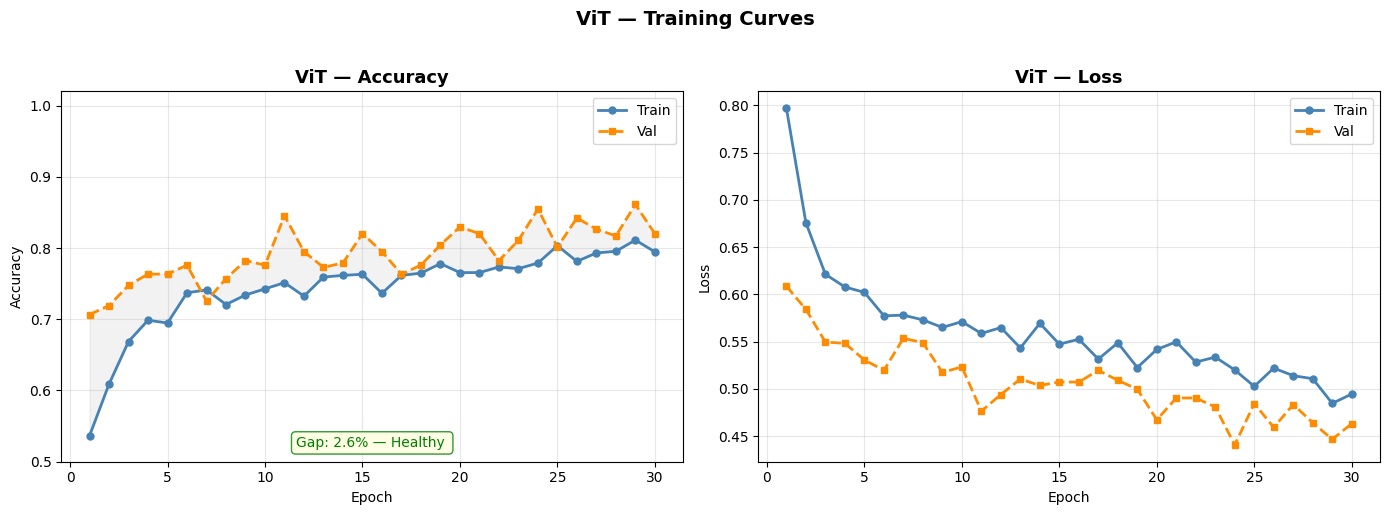

  Train Acc: 79.46%  |  Val Acc: 82.02%  |  Gap: 2.55%

 ViT Test Accuracy : 86.68%
ViT Test Loss     : 0.3759

Classification Report — ViT
              precision    recall  f1-score   support

      NORMAL       0.86      0.97      0.91       229
        PCOS       0.96      0.78      0.86       169

    accuracy                           0.89       398
   macro avg       0.91      0.88      0.89       398
weighted avg       0.90      0.89      0.89       398



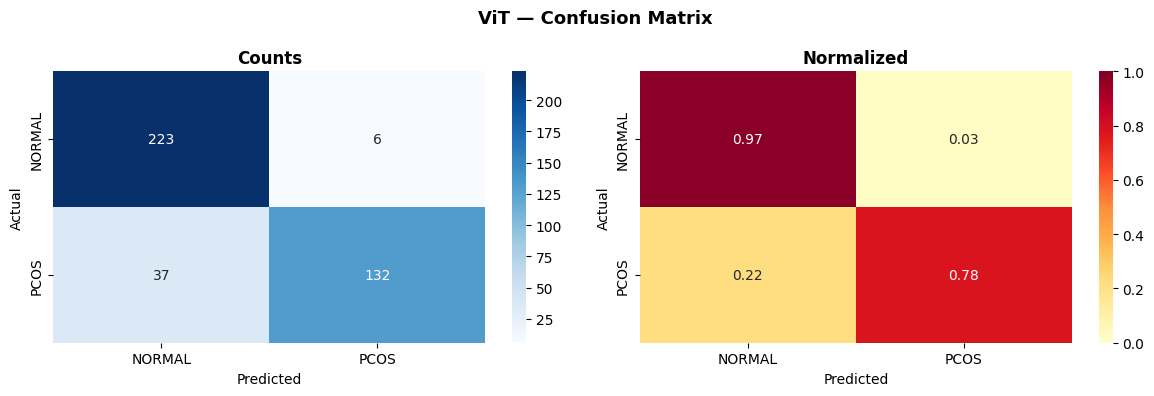

  Sensitivity (PCOS Recall)  : 78.1%
  Specificity (Normal Recall): 97.4%

 ViT evaluation done. Results stored.


In [ ]:
plot_history(vit_history, 'ViT')
vit_results = evaluate_model(vit_model, vit_test_gen, 'ViT', vit_class_names)
all_results['ViT'] = vit_results
print('\n ViT evaluation done. Results stored.')

In [ ]:
print('\n  Training ViT...')
vit_history = vit_model.fit(
    vit_train_gen,
    epochs=EPOCHS,
    validation_data=vit_val_gen,
    class_weight=vit_class_weights
)


  Training ViT...
Epoch 1/30
80/80 ━━━━━━━━━━━━━━━━━━━━ 15s 185ms/step - accuracy: 0.8017 - loss: 0.5044 - val_accuracy: 0.8423 - val_loss: 0.4352
Epoch 2/30
80/80 ━━━━━━━━━━━━━━━━━━━━ 17s 210ms/step - accuracy: 0.8112 - loss: 0.4854 - val_accuracy: 0.8864 - val_loss: 0.4055
Epoch 3/30
80/80 ━━━━━━━━━━━━━━━━━━━━ 16s 206ms/step - accuracy: 0.8009 - loss: 0.4914 - val_accuracy: 0.8360 - val_loss: 0.4539
Epoch 4/30
80/80 ━━━━━━━━━━━━━━━━━━━━ 15s 184ms/step - accuracy: 0.8261 - loss: 0.4950 - val_accuracy: 0.8517 - val_loss: 0.4151
Epoch 5/30
80/80 ━━━━━━━━━━━━━━━━━━━━ 15s 185ms/step - accuracy: 0.8214 - loss: 0.4755 - val_accuracy: 0.8517 - val_loss: 0.4247
Epoch 6/30
80/80 ━━━━━━━━━━━━━━━━━━━━ 15s 185ms/step - accuracy: 0.8371 - loss: 0.4719 - val_accuracy: 0.8644 - val_loss: 0.4262
Epoch 7/30
80/80 ━━━━━━━━━━━━━━━━━━━━ 15s 185ms/step - accuracy: 0.8387 - loss: 0.4492 - val_accuracy: 0.8675 - val_loss: 0.4079
Epoch 8/30
80/80 ━━━━━━━━━━━━━━━━━━━━ 15s 188ms/step - accuracy: 0.8395 - loss

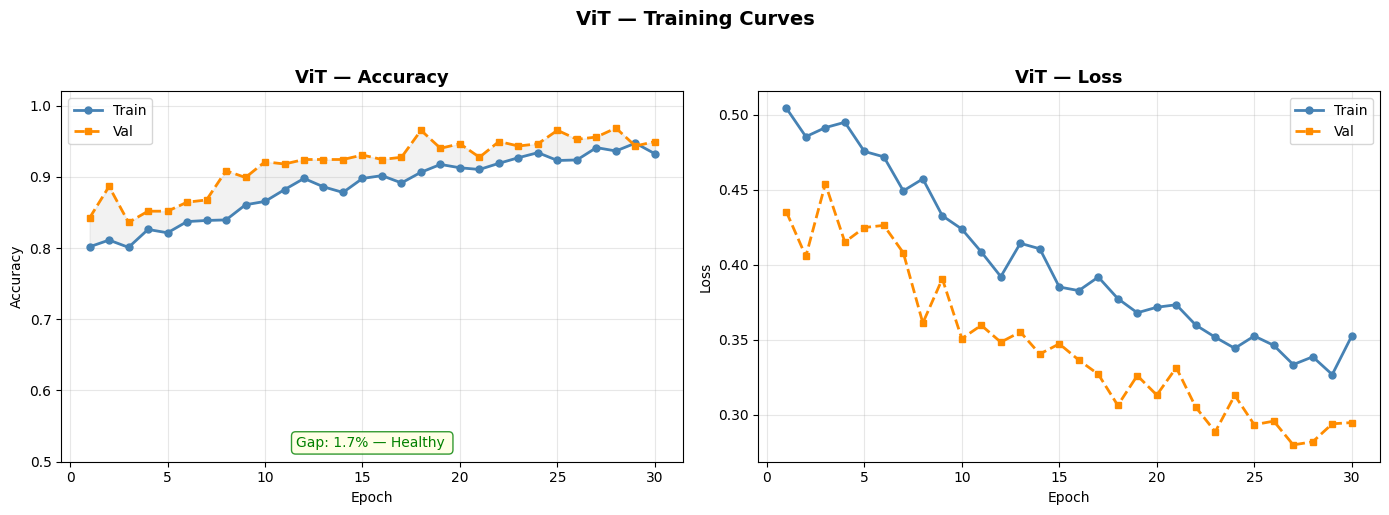

  Train Acc: 93.23%  |  Val Acc: 94.95%  |  Gap: 1.72%

 ViT Test Accuracy : 97.74%
ViT Test Loss     : 0.2616

Classification Report — ViT
              precision    recall  f1-score   support

      NORMAL       0.99      1.00      0.99       229
        PCOS       1.00      0.98      0.99       169

    accuracy                           0.99       398
   macro avg       0.99      0.99      0.99       398
weighted avg       0.99      0.99      0.99       398



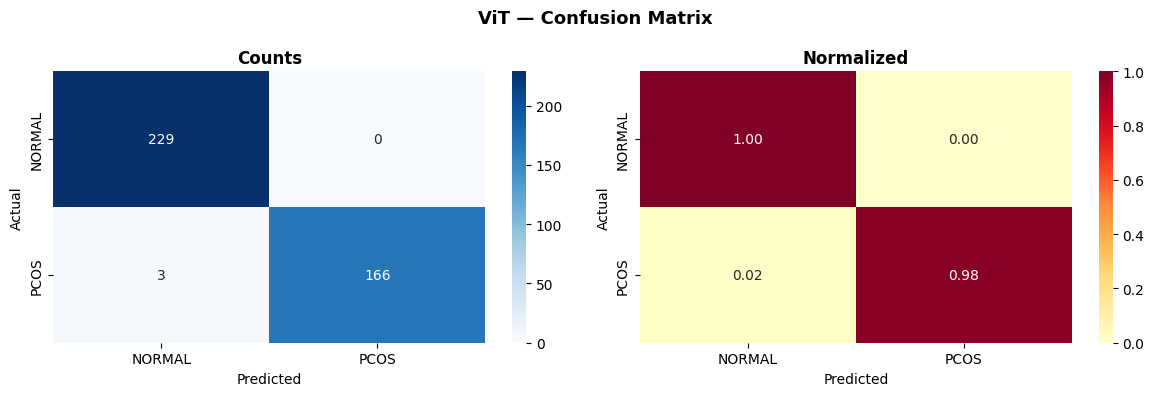

  Sensitivity (PCOS Recall)  : 98.2%
  Specificity (Normal Recall): 100.0%

 ViT evaluation done. Results stored.


In [ ]:
plot_history(vit_history, 'ViT')
vit_results = evaluate_model(vit_model, vit_test_gen, 'ViT', vit_class_names)
all_results['ViT'] = vit_results
print('\n ViT evaluation done. Results stored.')

In [ ]:
print('=' * 55)
print('  MODEL 5: Vision Transformer — Building...')
print('=' * 55)

vit_train_gen, vit_val_gen, vit_test_gen = build_generators(lambda x: x/255.0)
vit_class_names   = list(vit_train_gen.class_indices.keys())
vit_class_weights = get_class_weights(vit_train_gen)

from tensorflow.keras.layers import Lambda, Reshape, MultiHeadAttention, LayerNormalization

# Parameters (UPDATED)
PATCH_SIZE = 16
NUM_PATCHES = (128 // PATCH_SIZE) ** 2
PROJECTION_DIM = 96   # slightly increased
NUM_HEADS = 4
NUM_BLOCKS = 2        # ✅ NEW

# Input
inputs = tf.keras.Input(shape=(128, 128, 3))

# Patch extraction
patches = Lambda(lambda x: tf.image.extract_patches(
    images=x,
    sizes=[1, PATCH_SIZE, PATCH_SIZE, 1],
    strides=[1, PATCH_SIZE, PATCH_SIZE, 1],
    rates=[1, 1, 1, 1],
    padding='VALID'
))(inputs)

# Reshape
patches = Reshape((NUM_PATCHES, PATCH_SIZE * PATCH_SIZE * 3))(patches)

# Projection
x = Dense(PROJECTION_DIM)(patches)

# =========================
# 🔥 Transformer Blocks (2x)
# =========================
for _ in range(NUM_BLOCKS):

    # Multi-head attention
    attn_output = MultiHeadAttention(
        num_heads=NUM_HEADS,
        key_dim=PROJECTION_DIM
    )(x, x)

    x = LayerNormalization()(x + attn_output)

    # Feed-forward network
    ffn = Dense(PROJECTION_DIM, activation='relu')(x)
    x = LayerNormalization()(x + ffn)

# =========================
# Classification head
# =========================
x = Flatten()(x)
x = GaussianNoise(0.2)(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.4)(x)   # slightly reduced
x = Dense(64, activation='relu')(x)
x = Dropout(0.4)(x)
vit_out = Dense(1, activation='sigmoid')(x)

vit_model = Model(inputs=inputs, outputs=vit_out)

vit_model.compile(
    optimizer=Adam(learning_rate=5e-5),
    loss=BinaryCrossentropy(label_smoothing=0.1),
    metrics=['accuracy']
)

trainable = sum([tf.size(w).numpy() for w in vit_model.trainable_weights])
print(f'Trainable params  : {trainable:,}')
print(f'Total params      : {vit_model.count_params():,}')
print('\n ViT model built.')

  MODEL 5: Vision Transformer — Building...
Found 1271 images belonging to 2 classes.
Found 317 images belonging to 2 classes.
Found 398 images belonging to 2 classes.
  Class weights: {np.int32(0): np.float64(0.8693570451436389), np.int32(1): np.float64(1.1768518518518518)}
Trainable params  : 1,185,505
Total params      : 1,185,505

 ViT model built.


---
# SECTION 12: K-Fold Cross Validation (All 5 Models)
K-Fold (k=5) is run on the **full training set** to get robust, unbiased accuracy estimates.
Each fold trains a fresh model, evaluates on the held-out fold, then reports mean ± std across folds.

In [ ]:
# ============================================================
# SECTION 12: K-Fold Cross Validation (k=5)
# ============================================================
import os, gc, glob
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# ── 1. Collect ALL training image paths + labels ─────────────────────
def collect_image_paths(directory):
    """Walk a directory with class sub-folders and return (paths, labels) arrays."""
    class_names = sorted([
        d for d in os.listdir(directory)
        if os.path.isdir(os.path.join(directory, d))
    ])
    paths, labels = [], []
    for label_idx, cls in enumerate(class_names):
        cls_dir = os.path.join(directory, cls)
        for ext in ('*.jpg', '*.jpeg', '*.png', '*.bmp'):
            for fp in glob.glob(os.path.join(cls_dir, ext)):
                paths.append(fp)
                labels.append(label_idx)
    return np.array(paths), np.array(labels), class_names

all_paths, all_labels, KFOLD_CLASS_NAMES = collect_image_paths(TRAIN_DIR)
print(f'Total training images : {len(all_paths)}')
print(f'Class names           : {KFOLD_CLASS_NAMES}')
print(f'Label distribution    : {dict(zip(*np.unique(all_labels, return_counts=True)))}')

# ── 2. Data loader: load images from a list of paths ─────────────────
def load_images_from_paths(paths, labels, preprocess_fn,
                            img_size=IMG_SIZE, augment=False):
    """Return (X, y) numpy arrays for a list of file paths."""
    aug = ImageDataGenerator(
        preprocessing_function=preprocess_fn,
        rotation_range=40,
        zoom_range=0.3,
        horizontal_flip=True,
        vertical_flip=True,
        width_shift_range=0.25,
        height_shift_range=0.25,
        shear_range=0.20,
        brightness_range=[0.7, 1.3],
        fill_mode='reflect'
    ) if augment else ImageDataGenerator(preprocessing_function=preprocess_fn)

    X, y = [], []
    for path, label in zip(paths, labels):
        img = load_img(path, target_size=img_size)
        arr = img_to_array(img)
        if augment:
            arr = aug.random_transform(arr)
        arr = preprocess_fn(arr)
        X.append(arr)
        y.append(label)
    return np.array(X, dtype=np.float32), np.array(y, dtype=np.float32)

# ── 3. Model factory ─────────────────────────────────────────────────
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import (
    Conv2D, MaxPooling2D, Flatten, Dense, Dropout,
    BatchNormalization, GlobalAveragePooling2D, GaussianNoise,
    MultiHeadAttention, LayerNormalization, Reshape, Lambda
)
from tensorflow.keras.applications import MobileNetV2, ResNet50V2, VGG16
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input as mobilenet_preprocess
from tensorflow.keras.applications.resnet_v2   import preprocess_input as resnet_preprocess
from tensorflow.keras.applications.vgg16       import preprocess_input as vgg_preprocess
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import BinaryCrossentropy
from tensorflow.keras import regularizers

def build_cnn():
    model = Sequential([
        GaussianNoise(0.05, input_shape=(128, 128, 3)),
        Conv2D(32, (3,3), activation='relu', padding='same', kernel_regularizer=regularizers.l2(0.001)),
        BatchNormalization(), MaxPooling2D(2,2), Dropout(0.25),
        Conv2D(64, (3,3), activation='relu', padding='same', kernel_regularizer=regularizers.l2(0.001)),
        BatchNormalization(), MaxPooling2D(2,2), Dropout(0.25),
        Conv2D(128, (3,3), activation='relu', padding='same', kernel_regularizer=regularizers.l2(0.001)),
        BatchNormalization(), MaxPooling2D(2,2), Dropout(0.30),
        Flatten(),
        Dense(128, activation='relu', kernel_regularizer=regularizers.l2(0.01)), Dropout(0.50),
        Dense(1, activation='sigmoid')
    ])
    model.compile(optimizer=Adam(5e-4), loss=BinaryCrossentropy(label_smoothing=0.15), metrics=['accuracy'])
    return model

def build_mobilenetv2():
    base = MobileNetV2(input_shape=(128,128,3), include_top=False, weights='imagenet')
    base.trainable = True
    for layer in base.layers[:-10]: layer.trainable = False
    x = GlobalAveragePooling2D()(base.output)
    x = GaussianNoise(0.20)(x); x = BatchNormalization()(x)
    x = Dense(128, activation='relu', kernel_regularizer=regularizers.l2(0.01))(x); x = Dropout(0.30)(x)
    x = Dense(64,  activation='relu', kernel_regularizer=regularizers.l2(0.01))(x); x = Dropout(0.30)(x)
    out = Dense(1, activation='sigmoid')(x)
    m = Model(inputs=base.input, outputs=out)
    m.compile(optimizer=Adam(1e-5), loss=BinaryCrossentropy(label_smoothing=0.05), metrics=['accuracy'])
    return m

def build_resnet50v2():
    base = ResNet50V2(input_shape=(128,128,3), include_top=False, weights='imagenet')
    base.trainable = True
    for layer in base.layers: layer.trainable = False
    for layer in base.layers:
        if any(layer.name.startswith(b) for b in ['conv5_block2', 'conv5_block3']):
            layer.trainable = True
    x = GlobalAveragePooling2D()(base.output)
    x = GaussianNoise(0.35)(x); x = BatchNormalization()(x)
    x = Dense(128, activation='relu', kernel_regularizer=regularizers.l2(0.02))(x); x = Dropout(0.50)(x)
    x = Dense(64,  activation='relu', kernel_regularizer=regularizers.l2(0.02))(x); x = Dropout(0.40)(x)
    out = Dense(1, activation='sigmoid')(x)
    m = Model(inputs=base.input, outputs=out)
    m.compile(optimizer=Adam(1e-5), loss=BinaryCrossentropy(label_smoothing=0.15), metrics=['accuracy'])
    return m



def build_vit():
    PATCH_SIZE = 16; NUM_PATCHES = (128 // PATCH_SIZE)**2
    PROJECTION_DIM = 96; NUM_HEADS = 4; NUM_BLOCKS = 2
    inputs = tf.keras.Input(shape=(128, 128, 3))
    patches = Lambda(lambda x: tf.image.extract_patches(
        images=x, sizes=[1,PATCH_SIZE,PATCH_SIZE,1],
        strides=[1,PATCH_SIZE,PATCH_SIZE,1], rates=[1,1,1,1], padding='VALID'
    ))(inputs)
    patches = Reshape((NUM_PATCHES, PATCH_SIZE*PATCH_SIZE*3))(patches)
    x = Dense(PROJECTION_DIM)(patches)
    for _ in range(NUM_BLOCKS):
        attn_out = MultiHeadAttention(num_heads=NUM_HEADS, key_dim=PROJECTION_DIM)(x, x)
        x = LayerNormalization()(x + attn_out)
        ffn = Dense(PROJECTION_DIM, activation='relu')(x)
        x = LayerNormalization()(x + ffn)
    x = Flatten()(x)
    x = GaussianNoise(0.2)(x)
    x = Dense(128, activation='relu')(x); x = Dropout(0.4)(x)
    x = Dense(64,  activation='relu')(x); x = Dropout(0.4)(x)
    out = Dense(1, activation='sigmoid')(x)
    m = Model(inputs=inputs, outputs=out)
    m.compile(optimizer=Adam(5e-5), loss=BinaryCrossentropy(label_smoothing=0.1), metrics=['accuracy'])
    return m

print('\u2705 K-Fold helper functions and model factories ready.')


Total training images : 1588
Class names           : ['NORMAL', 'PCOS']
Label distribution    : {np.int64(0): np.int64(913), np.int64(1): np.int64(675)}
✅ K-Fold helper functions and model factories ready.


In [ ]:
# ── 4. Run K-Fold Cross Validation ───────────────────────────────────
K_FOLDS    = 5
KFOLD_EPOCHS = 10   # fewer epochs per fold for speed; increase if needed

# Map: model_name → (builder_fn, preprocess_fn)
MODEL_REGISTRY = {
    'CNN'        : (build_cnn,        lambda x: x / 255.0),
    'MobileNetV2': (build_mobilenetv2, mobilenet_preprocess),
    'ResNet50V2' : (build_resnet50v2,  resnet_preprocess),
    'ViT'        : (build_vit,         lambda x: x / 255.0),
}

kfold_results = {}   # model_name -> list of per-fold val_accuracies

skf = StratifiedKFold(n_splits=K_FOLDS, shuffle=True, random_state=SEED)

callbacks_kfold = [
    EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True, verbose=0),
    ReduceLROnPlateau(monitor='val_loss', factor=0.3, patience=2, min_lr=1e-8, verbose=0)
]

for model_name, (builder_fn, preprocess_fn) in MODEL_REGISTRY.items():
    print('\n' + '=' * 60)
    print(f'  K-Fold ({K_FOLDS}-Fold) — {model_name}')
    print('=' * 60)

    fold_val_accs = []

    for fold_idx, (train_idx, val_idx) in enumerate(skf.split(all_paths, all_labels), start=1):
        print(f'\n  ▶ Fold {fold_idx}/{K_FOLDS}')

        train_paths_fold = all_paths[train_idx]
        train_labels_fold = all_labels[train_idx]
        val_paths_fold   = all_paths[val_idx]
        val_labels_fold  = all_labels[val_idx]

        # Load images (augment train, no-aug val)
        X_train, y_train = load_images_from_paths(train_paths_fold, train_labels_fold,
                                                   preprocess_fn, augment=True)
        X_val,   y_val   = load_images_from_paths(val_paths_fold,   val_labels_fold,
                                                   preprocess_fn, augment=False)

        # Class weights for this fold
        cw_vals  = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
        cw_dict  = dict(zip(np.unique(y_train).astype(int), cw_vals))

        # Build fresh model
        tf.keras.backend.clear_session()
        model = builder_fn()

        # Train
        history = model.fit(
            X_train, y_train,
            validation_data=(X_val, y_val),
            epochs=KFOLD_EPOCHS,
            batch_size=BATCH_SIZE,
            class_weight=cw_dict,
            callbacks=callbacks_kfold,
            verbose=0
        )

        best_val_acc = max(history.history['val_accuracy'])
        fold_val_accs.append(best_val_acc)
        print(f'     Best val_accuracy: {best_val_acc*100:.2f}%')

        # Free memory
        del model, X_train, y_train, X_val, y_val, history
        gc.collect()

    kfold_results[model_name] = fold_val_accs
    mean_acc = np.mean(fold_val_accs) * 100
    std_acc  = np.std(fold_val_accs) * 100
    print(f'\n  {model_name}  ➜  Mean Val Acc: {mean_acc:.2f}% \u00b1 {std_acc:.2f}%')

print('\n\u2705 K-Fold Cross Validation complete!')



  K-Fold (5-Fold) — CNN

  ▶ Fold 1/5
     Best val_accuracy: 83.65%

  ▶ Fold 2/5
     Best val_accuracy: 67.92%

  ▶ Fold 3/5
     Best val_accuracy: 57.55%

  ▶ Fold 4/5
     Best val_accuracy: 57.41%

  ▶ Fold 5/5
     Best val_accuracy: 57.41%

  CNN  ➜  Mean Val Acc: 64.79% ± 10.26%

  K-Fold (5-Fold) — MobileNetV2

  ▶ Fold 1/5
     Best val_accuracy: 90.88%

  ▶ Fold 2/5
     Best val_accuracy: 87.74%

  ▶ Fold 3/5
     Best val_accuracy: 86.16%

  ▶ Fold 4/5
     Best val_accuracy: 79.18%

  ▶ Fold 5/5
     Best val_accuracy: 88.96%

  MobileNetV2  ➜  Mean Val Acc: 86.58% ± 4.01%

  K-Fold (5-Fold) — ResNet50V2

  ▶ Fold 1/5
     Best val_accuracy: 92.45%

  ▶ Fold 2/5
     Best val_accuracy: 95.91%

  ▶ Fold 3/5
     Best val_accuracy: 84.59%

  ▶ Fold 4/5
     Best val_accuracy: 79.50%

  ▶ Fold 5/5
     Best val_accuracy: 72.87%

  ResNet50V2  ➜  Mean Val Acc: 85.06% ± 8.39%

  K-Fold (5-Fold) — ViT

  ▶ Fold 1/5
     Best val_accuracy: 82.39%

  ▶ Fold 2/5
     Best val_a

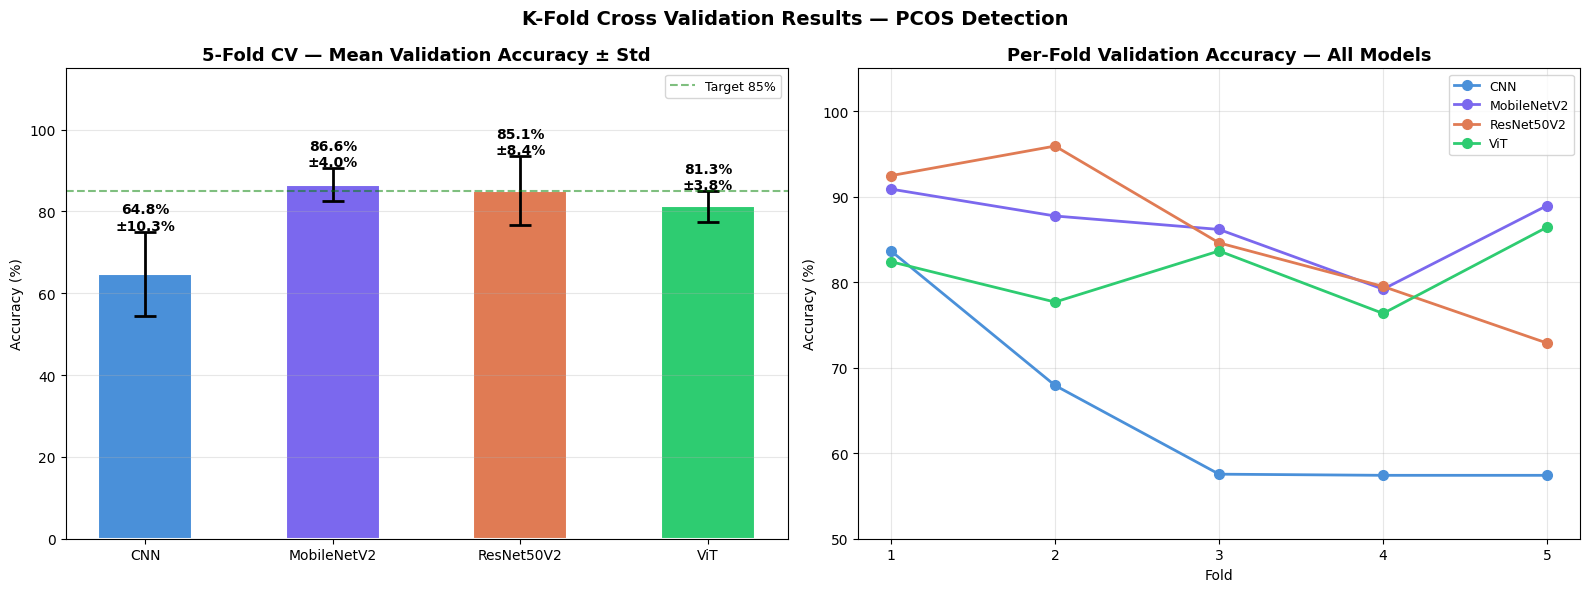


  Model                                         Fold Accuracies     Mean     Std
  ------------------------------------------------------------------
  CNN             ['83.6%', '67.9%', '57.5%', '57.4%', '57.4%']   64.79%  10.26%
  MobileNetV2     ['90.9%', '87.7%', '86.2%', '79.2%', '89.0%']   86.58%   4.01%
  ResNet50V2      ['92.5%', '95.9%', '84.6%', '79.5%', '72.9%']   85.06%   8.39%
  ViT             ['82.4%', '77.7%', '83.6%', '76.3%', '86.4%']   81.30%   3.76%

🏆 Best model by K-Fold CV: MobileNetV2  (86.58% ± 4.01%)


In [ ]:
# ── 5. Visualize K-Fold Results ───────────────────────────────────────
model_names_kf = list(kfold_results.keys())
means  = [np.mean(kfold_results[m]) * 100 for m in model_names_kf]
stds   = [np.std(kfold_results[m])  * 100 for m in model_names_kf]
colors_kf = ['#4A90D9', '#7B68EE', '#E07B54', '#2ECC71', '#E74C3C']

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- Plot 1: Mean ± Std bar chart ---
bars = axes[0].bar(model_names_kf, means, yerr=stds,
                    color=colors_kf, width=0.5, capsize=8,
                    edgecolor='white', linewidth=1.5,
                    error_kw={'elinewidth': 2, 'ecolor': 'black', 'capthick': 2})
for bar, m, s in zip(bars, means, stds):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                  bar.get_height() + s + 0.5,
                  f'{m:.1f}%\n\u00b1{s:.1f}%',
                  ha='center', fontsize=10, fontweight='bold')
axes[0].set_title(f'{K_FOLDS}-Fold CV — Mean Validation Accuracy ± Std',
                   fontsize=13, fontweight='bold')
axes[0].set_ylabel('Accuracy (%)')
axes[0].set_ylim([0, 115])
axes[0].axhline(y=85, color='green', linestyle='--', alpha=0.5, label='Target 85%')
axes[0].legend(fontsize=9)
axes[0].grid(axis='y', alpha=0.3)

# --- Plot 2: Per-fold accuracy per model (line plot) ---
for i, (m, color) in enumerate(zip(model_names_kf, colors_kf)):
    fold_accs = [v * 100 for v in kfold_results[m]]
    axes[1].plot(range(1, K_FOLDS+1), fold_accs,
                  marker='o', linewidth=2, markersize=7,
                  label=m, color=color)
axes[1].set_title('Per-Fold Validation Accuracy — All Models',
                   fontsize=13, fontweight='bold')
axes[1].set_xlabel('Fold')
axes[1].set_ylabel('Accuracy (%)')
axes[1].set_xticks(range(1, K_FOLDS+1))
axes[1].set_ylim([50, 105])
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.3)

plt.suptitle('K-Fold Cross Validation Results — PCOS Detection',
              fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# --- Summary table ---
print('\n' + '=' * 70)
print(f"  {'Model':<15} {'Fold Accuracies':>45}  {'Mean':>7}  {'Std':>6}")
print('  ' + '-' * 66)
for m in model_names_kf:
    fa  = [f'{v*100:.1f}%' for v in kfold_results[m]]
    mn  = np.mean(kfold_results[m]) * 100
    sd  = np.std(kfold_results[m])  * 100
    print(f"  {m:<15} {str(fa):>45}  {mn:>6.2f}%  {sd:>5.2f}%")
print('=' * 70)

best_kf = max(kfold_results, key=lambda m: np.mean(kfold_results[m]))
print(f'\n\U0001f3c6 Best model by K-Fold CV: {best_kf}  '
      f'({np.mean(kfold_results[best_kf])*100:.2f}% \u00b1 {np.std(kfold_results[best_kf])*100:.2f}%)')